In [1]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ==========================================
# STAGE 6 CONFIGURATION
# ==========================================

DATA_DIR = (
    "/content/drive/MyDrive/"
    "exoplanet_pipeline/data"
)

stage4_path = os.path.join(
    DATA_DIR,
    "stage4_output.pkl"
)

stage5_path = os.path.join(
    DATA_DIR,
    "stage5_output.pkl"
)

stage6_path = os.path.join(
    DATA_DIR,
    "stage6_output.pkl"
)

ODDITY_CONFIG = {
    # Blend-risk boundaries
    "low_blend_threshold": 0.10,
    "high_blend_threshold": 0.30,

    # Variability boundary
    "variability_scatter_threshold": 0.02,

    # Standard blend-dependent weights
    "low_blend_weights": {
        "autoencoder": 0.50,
        "physics": 0.50
    },

    "medium_blend_weights": {
        "autoencoder": 0.40,
        "physics": 0.60
    },

    "high_blend_weights": {
        "autoencoder": 0.30,
        "physics": 0.70
    },

    # Variability-dependent weights
    "quiet_star_weights": {
        "autoencoder": 0.60,
        "physics": 0.40
    },

    "noisy_star_weights": {
        "autoencoder": 0.30,
        "physics": 0.70
    },

    # Final thresholds
    "followup_threshold": 0.80,
    "candidate_threshold": 0.50
}

print(ODDITY_CONFIG)

{'low_blend_threshold': 0.1, 'high_blend_threshold': 0.3, 'variability_scatter_threshold': 0.02, 'low_blend_weights': {'autoencoder': 0.5, 'physics': 0.5}, 'medium_blend_weights': {'autoencoder': 0.4, 'physics': 0.6}, 'high_blend_weights': {'autoencoder': 0.3, 'physics': 0.7}, 'quiet_star_weights': {'autoencoder': 0.6, 'physics': 0.4}, 'noisy_star_weights': {'autoencoder': 0.3, 'physics': 0.7}, 'followup_threshold': 0.8, 'candidate_threshold': 0.5}


In [3]:
# ==========================================
# LOAD PREVIOUS STAGE OUTPUTS
# ==========================================

stage1_path = os.path.join(
    DATA_DIR,
    "stage1_output.pkl"
)

if not os.path.isfile(stage1_path):
    raise FileNotFoundError(
        f"Stage 1 output not found: {stage1_path}"
    )

if not os.path.isfile(stage4_path):
    raise FileNotFoundError(
        f"Stage 4 output not found: {stage4_path}"
    )

if not os.path.isfile(stage5_path):
    raise FileNotFoundError(
        f"Stage 5 output not found: {stage5_path}"
    )

with open(stage1_path, "rb") as f:
    stage1 = pickle.load(f)

with open(stage4_path, "rb") as f:
    stage4 = pickle.load(f)

with open(stage5_path, "rb") as f:
    stage5 = pickle.load(f)

print("Stage 1 keys:", stage1.keys())
print("Stage 4 keys:", stage4.keys())
print("Stage 5 keys:", stage5.keys())

Stage 1 keys: dict_keys(['time', 'flux', 'flux_err', 'tic_id', 'crowdsap', 'ra', 'dec', 'sector'])
Stage 4 keys: dict_keys(['tic_id', 'stage3', 'candidate', 'windowing', 'training', 'anomaly_detection', 'reliability', 'preprocessing', 'model_path', 'config'])
Stage 5 keys: dict_keys(['tic_id', 'ra', 'dec', 'crowdsap', 'period', 'duration', 't0', 'physics_score', 'forensic_score', 'approx_fpp', 'bayesian_fpp', 'planet_probability', 'confidence', 'classification', 'centroid_shift', 'centroid_score', 'centroid_flag', 'pixel_offset', 'pixel_score', 'blend_risk', 'blend_risk_flag', 'tpf_available', 'physics_metrics', 'advanced_metrics', 'weights', 'interpretation', 'strengths', 'concerns'])


In [4]:
# ==========================================
# HELPER FUNCTIONS
# ==========================================

def safe_float(
    value,
    default=np.nan
):
    try:
        value = float(value)

        if np.isfinite(value):
            return value

    except (
        TypeError,
        ValueError
    ):
        pass

    return default


def clip_score(value):
    value = safe_float(
        value,
        default=0.0
    )

    return float(
        np.clip(
            value,
            0.0,
            1.0
        )
    )


def normalize_blend_flag(flag):
    if flag is None:
        return None

    flag = str(flag).strip().upper()

    if flag in {
        "LOW",
        "MEDIUM",
        "HIGH"
    }:
        return flag

    return None

In [5]:
# ==========================================
# EXTRACT STAGE 4 VARIABLES
# ==========================================

tic_id = stage1.get(
    "tic_id",
    stage1.get("tic_id")
)

anomaly_data = stage4.get(
    "anomaly_detection",
    {}
)

reliability_data = stage4.get(
    "reliability",
    {}
)

autoencoder_score = clip_score(
    anomaly_data.get(
        "candidate_anomaly_score",
        0.0
    )
)

candidate_detected = bool(
    anomaly_data.get(
        "candidate_detected",
        False
    )
)

autoencoder_reliable = bool(
    reliability_data.get(
        "autoencoder_reliable",
        False
    )
)

normal_scatter = safe_float(
    reliability_data.get(
        "normal_scatter"
    )
)

high_variability_warning = bool(
    reliability_data.get(
        "high_variability_warning",
        False
    )
)

blend_metric = safe_float(
    reliability_data.get(
        "blend_metric"
    )
)

blend_metric_source = reliability_data.get(
    "blend_metric_source",
    "unavailable"
)

reliability_reasons = reliability_data.get(
    "reliability_reasons",
    []
)

stage5_blend_flag = normalize_blend_flag(
    stage5.get("blend_risk_flag")
)

print("TIC ID:", tic_id)
print("Autoencoder Score:", autoencoder_score)
print("Candidate Detected:", candidate_detected)
print("Autoencoder Reliable:", autoencoder_reliable)
print("Normal Scatter:", normal_scatter)
print("Blend Metric:", blend_metric)
print("Blend Source:", blend_metric_source)
print("Reliability Reasons:", reliability_reasons)
print(
    "Stage 5 Blend Risk Flag:",
    stage5.get("blend_risk_flag")
)

TIC ID: 261136679
Autoencoder Score: 1.0
Candidate Detected: True
Autoencoder Reliable: True
Normal Scatter: 0.00011919696968883292
Blend Metric: nan
Blend Source: unavailable
Reliability Reasons: []
Stage 5 Blend Risk Flag: LOW


In [6]:
# ==========================================
# CALCULATE PHYSICS-ONLY SCORE
# ==========================================

physics_metrics = stage5.get(
    "physics_metrics",
    {}
)

metric_weights = stage5.get(
    "weights",
    {}
)

autoencoder_metric_names = {
    "autoencoder_anomaly",
    "autoencoder_reliability",
    "autoencoder_significance",
    "autoencoder_confidence"
}

physics_only_metrics = {}

physics_only_weights = {}

for metric, value in physics_metrics.items():

    if metric in autoencoder_metric_names:
        continue

    score = safe_float(value)

    if not np.isfinite(score):
        continue

    physics_only_metrics[metric] = float(
        np.clip(
            score,
            0.0,
            1.0
        )
    )

    physics_only_weights[metric] = safe_float(
        metric_weights.get(
            metric,
            1.0
        ),
        default=1.0
    )

if len(physics_only_metrics) == 0:
    raise ValueError(
        "No physics-only metrics were found "
        "in Stage 5 output."
    )

total_physics_weight = sum(
    physics_only_weights.values()
)

if total_physics_weight <= 0:
    raise ValueError(
        "Total physics metric weight must "
        "be greater than zero."
    )

physics_weighted_sum = 0.0

for metric, score in physics_only_metrics.items():

    physics_weighted_sum += (
        score
        *
        physics_only_weights[metric]
    )

physics_score = float(
    physics_weighted_sum
    /
    total_physics_weight
)

physics_score = clip_score(
    physics_score
)

print(
    "Original Stage 5 Score:",
    stage5.get("physics_score")
)

print(
    "Physics-Only Score:",
    physics_score
)

print(
    "Physics Metric Count:",
    len(physics_only_metrics)
)

Original Stage 5 Score: 0.6685853636934643
Physics-Only Score: 0.5968613470321162
Physics Metric Count: 13


In [7]:
# ==========================================
# PHYSICS-ONLY METRIC SUMMARY
# ==========================================

print("=" * 65)

print(
    "PHYSICS METRICS USED "
    "BY STAGE 6"
)

print("=" * 65)

for metric, score in physics_only_metrics.items():

    weight = physics_only_weights[
        metric
    ]

    print(
        f"{metric:32s}"
        f"Score={score:.3f}  "
        f"Weight={weight:.1f}"
    )

print("-" * 65)

print(
    f"Physics-Only Score: "
    f"{physics_score:.3f}"
)

PHYSICS METRICS USED BY STAGE 6
transit_depth                   Score=1.000  Weight=5.0
duration_ratio                  Score=1.000  Weight=4.0
symmetry                        Score=0.862  Weight=4.0
limb_darkening                  Score=0.317  Weight=5.0
v_shape                         Score=0.056  Weight=5.0
dilution                        Score=1.000  Weight=4.0
odd_even                        Score=0.500  Weight=5.0
secondary_eclipse               Score=0.000  Weight=5.0
ttv                             Score=0.500  Weight=4.0
ellipsoidal                     Score=1.000  Weight=5.0
rotation                        Score=1.000  Weight=4.0
eta                             Score=1.000  Weight=4.0
difference_image                Score=0.000  Weight=6.0
-----------------------------------------------------------------
Physics-Only Score: 0.597


In [8]:
# ==========================================
# RESOLVE BLEND RISK
# ==========================================

stage5_blend_flag = normalize_blend_flag(
    stage5.get(
        "blend_risk_flag"
    )
)

if np.isfinite(blend_metric):

    blend_risk_value = float(
        np.clip(
            blend_metric,
            0.0,
            1.0
        )
    )

    blend_risk_source = (
        blend_metric_source
    )

    if (
        blend_risk_value
        < ODDITY_CONFIG[
            "low_blend_threshold"
        ]
    ):

        blend_risk_level = "LOW"

    elif (
        blend_risk_value
        >= ODDITY_CONFIG[
            "high_blend_threshold"
        ]
    ):

        blend_risk_level = "HIGH"

    else:

        blend_risk_level = "MEDIUM"

elif stage5_blend_flag is not None:

    blend_risk_level = (
        stage5_blend_flag
    )

    blend_risk_source = (
        "stage5_blend_risk_flag"
    )

    blend_value_mapping = {
        "LOW": 0.05,
        "MEDIUM": 0.20,
        "HIGH": 0.50
    }

    blend_risk_value = (
        blend_value_mapping[
            blend_risk_level
        ]
    )

else:

    # Conservative fallback
    blend_risk_level = "MEDIUM"
    blend_risk_value = 0.20
    blend_risk_source = (
        "default_medium_fallback"
    )

print(
    "Blend Risk Value:",
    blend_risk_value
)

print(
    "Blend Risk Level:",
    blend_risk_level
)

print(
    "Blend Risk Source:",
    blend_risk_source
)

Blend Risk Value: 0.05
Blend Risk Level: LOW
Blend Risk Source: stage5_blend_risk_flag


In [9]:
# ==========================================
# STELLAR VARIABILITY CLASSIFICATION
# ==========================================

variability_threshold = (
    ODDITY_CONFIG[
        "variability_scatter_threshold"
    ]
)

if np.isfinite(normal_scatter):

    if normal_scatter > variability_threshold:

        variability_class = "NOISY"

    else:

        variability_class = "QUIET"

else:

    if high_variability_warning:

        variability_class = "NOISY"

    else:

        variability_class = "UNKNOWN"

print(
    "Normal Scatter:",
    normal_scatter
)

print(
    "Variability Threshold:",
    variability_threshold
)

print(
    "Variability Class:",
    variability_class
)

Normal Scatter: 0.00011919696968883292
Variability Threshold: 0.02
Variability Class: QUIET


In [10]:
# ==========================================
# ADAPTIVE WEIGHT SELECTION
# ==========================================

weighting_reasons = []

if variability_class == "NOISY":

    selected_weights = (
        ODDITY_CONFIG[
            "noisy_star_weights"
        ]
    )

    weighting_mode = (
        "NOISY_STAR_PHYSICS_PRIORITY"
    )

    weighting_reasons.append(
        "High stellar variability detected"
    )

elif blend_risk_level == "HIGH":

    selected_weights = (
        ODDITY_CONFIG[
            "high_blend_weights"
        ]
    )

    weighting_mode = (
        "HIGH_BLEND_PHYSICS_PRIORITY"
    )

    weighting_reasons.append(
        "High contamination or blending risk"
    )

elif (
    variability_class == "QUIET"
    and blend_risk_level == "LOW"
    and autoencoder_reliable
):

    selected_weights = (
        ODDITY_CONFIG[
            "quiet_star_weights"
        ]
    )

    weighting_mode = (
        "QUIET_STAR_AUTOENCODER_PRIORITY"
    )

    weighting_reasons.append(
        "Quiet star with low contamination"
    )

elif blend_risk_level == "LOW":

    selected_weights = (
        ODDITY_CONFIG[
            "low_blend_weights"
        ]
    )

    weighting_mode = (
        "LOW_BLEND_BALANCED"
    )

    weighting_reasons.append(
        "Low contamination risk"
    )

elif blend_risk_level == "MEDIUM":

    selected_weights = (
        ODDITY_CONFIG[
            "medium_blend_weights"
        ]
    )

    weighting_mode = (
        "MEDIUM_BLEND_PHYSICS_PRIORITY"
    )

    weighting_reasons.append(
        "Moderate contamination risk"
    )

else:

    selected_weights = (
        ODDITY_CONFIG[
            "high_blend_weights"
        ]
    )

    weighting_mode = (
        "HIGH_BLEND_PHYSICS_PRIORITY"
    )

    weighting_reasons.append(
        "High contamination risk"
    )

autoencoder_weight = float(
    selected_weights[
        "autoencoder"
    ]
)

physics_weight = float(
    selected_weights[
        "physics"
    ]
)

print(
    "Weighting Mode:",
    weighting_mode
)

print(
    "Autoencoder Weight:",
    autoencoder_weight
)

print(
    "Physics Weight:",
    physics_weight
)

print(
    "Reasons:",
    weighting_reasons
)

Weighting Mode: QUIET_STAR_AUTOENCODER_PRIORITY
Autoencoder Weight: 0.6
Physics Weight: 0.4
Reasons: ['Quiet star with low contamination']


In [11]:
# ==========================================
# VALIDATE ADAPTIVE WEIGHTS
# ==========================================

weight_sum = (
    autoencoder_weight
    +
    physics_weight
)

if not np.isclose(
    weight_sum,
    1.0
):
    raise ValueError(
        "Stage 6 weights must sum to 1.0. "
        f"Current sum: {weight_sum}"
    )

if (
    autoencoder_weight < 0
    or physics_weight < 0
):
    raise ValueError(
        "Stage 6 weights cannot be negative."
    )

print(
    "Weight validation passed."
)

print(
    "Weight Sum:",
    weight_sum
)

Weight validation passed.
Weight Sum: 1.0


In [12]:
# ==========================================
# ADAPTIVE ODDITY SCORE
# ==========================================

autoencoder_component = (
    autoencoder_weight
    *
    autoencoder_score
)

physics_component = (
    physics_weight
    *
    physics_score
)

oddity_score = (
    autoencoder_component
    +
    physics_component
)

oddity_score = clip_score(
    oddity_score
)

print(
    "Autoencoder Component:",
    autoencoder_component
)

print(
    "Physics Component:",
    physics_component
)

print(
    "Adaptive Oddity Score Ω:",
    oddity_score
)

Autoencoder Component: 0.6
Physics Component: 0.23874453881284652
Adaptive Oddity Score Ω: 0.8387445388128465


In [13]:
# ==========================================
# FINAL ODDITY CLASSIFICATION
# ==========================================

followup_threshold = (
    ODDITY_CONFIG[
        "followup_threshold"
    ]
)

candidate_threshold = (
    ODDITY_CONFIG[
        "candidate_threshold"
    ]
)

if oddity_score >= followup_threshold:

    oddity_classification = (
        "HIGH-CONFIDENCE PLANET"
    )

    recommendation = (
        "RECOMMEND TELESCOPE FOLLOW-UP"
    )

    priority = "HIGH"

elif oddity_score >= candidate_threshold:

    oddity_classification = (
        "PLANET CANDIDATE"
    )

    recommendation = (
        "NEEDS MORE DATA"
    )

    priority = "MEDIUM"

else:

    oddity_classification = (
        "LIKELY FALSE POSITIVE"
    )

    recommendation = (
        "REJECT OR MANUALLY REVIEW"
    )

    priority = "LOW"

print(
    "Classification:",
    oddity_classification
)

print(
    "Recommendation:",
    recommendation
)

print(
    "Priority:",
    priority
)

Classification: HIGH-CONFIDENCE PLANET
Recommendation: RECOMMEND TELESCOPE FOLLOW-UP
Priority: HIGH


In [14]:
# ==========================================
# RELIABILITY AND REVIEW WARNINGS
# ==========================================

stage6_warnings = []

if not autoencoder_reliable:

    stage6_warnings.append(
        "Stage 4 marked the autoencoder as unreliable"
    )

if not candidate_detected:

    stage6_warnings.append(
        "Autoencoder did not independently detect the candidate"
    )

if blend_risk_level == "HIGH":

    stage6_warnings.append(
        "High blending or contamination risk"
    )

if variability_class == "NOISY":

    stage6_warnings.append(
        "High out-of-transit stellar variability"
    )

if physics_score < 0.50:

    stage6_warnings.append(
        "Physics-only validation score is below 0.50"
    )

if (
    oddity_score >= followup_threshold
    and len(stage6_warnings) > 0
):

    recommendation = (
        "MANUAL REVIEW BEFORE "
        "TELESCOPE FOLLOW-UP"
    )

print(
    "Warnings:",
    len(stage6_warnings)
)

if len(stage6_warnings) == 0:

    print(
        "✓ No major reliability warnings"
    )

else:

    for warning in stage6_warnings:

        print(
            f"⚠ {warning}"
        )

Warnings: 0
✓ No major reliability warnings


In [15]:
# ==========================================
# STAGE 6 FINAL REPORT
# ==========================================

print("\n")
print("=" * 72)
print("STAGE 6: ADAPTIVE ODDITY SCORE REPORT")
print("=" * 72)

print(
    f"TIC ID                    : "
    f"{tic_id}"
)

print(
    f"Autoencoder Score Â       : "
    f"{autoencoder_score:.3f}"
)

print(
    f"Physics-Only Score P̂     : "
    f"{physics_score:.3f}"
)

print("-" * 72)

print(
    f"Blend Risk Value          : "
    f"{blend_risk_value:.3f}"
)

print(
    f"Blend Risk Level          : "
    f"{blend_risk_level}"
)

print(
    f"Variability Class         : "
    f"{variability_class}"
)

print(
    f"Autoencoder Reliable      : "
    f"{autoencoder_reliable}"
)

print("-" * 72)

print(
    f"Weighting Mode            : "
    f"{weighting_mode}"
)

print(
    f"Autoencoder Weight        : "
    f"{autoencoder_weight:.2f}"
)

print(
    f"Physics Weight            : "
    f"{physics_weight:.2f}"
)

print("-" * 72)

print(
    f"Autoencoder Contribution  : "
    f"{autoencoder_component:.3f}"
)

print(
    f"Physics Contribution      : "
    f"{physics_component:.3f}"
)

print(
    f"Adaptive Oddity Score Ω   : "
    f"{oddity_score:.3f}"
)

print("-" * 72)

print(
    f"Classification            : "
    f"{oddity_classification}"
)

print(
    f"Priority                  : "
    f"{priority}"
)

print(
    f"Recommended Action        : "
    f"{recommendation}"
)

print("-" * 72)

if len(stage6_warnings) == 0:

    print(
        "Warnings                  : None"
    )

else:

    print("Warnings:")

    for warning in stage6_warnings:

        print(
            f"  ⚠ {warning}"
        )

print("=" * 72)



STAGE 6: ADAPTIVE ODDITY SCORE REPORT
TIC ID                    : 261136679
Autoencoder Score Â       : 1.000
Physics-Only Score P̂     : 0.597
------------------------------------------------------------------------
Blend Risk Value          : 0.050
Blend Risk Level          : LOW
Variability Class         : QUIET
Autoencoder Reliable      : True
------------------------------------------------------------------------
Weighting Mode            : QUIET_STAR_AUTOENCODER_PRIORITY
Autoencoder Weight        : 0.60
Physics Weight            : 0.40
------------------------------------------------------------------------
Autoencoder Contribution  : 0.600
Physics Contribution      : 0.239
Adaptive Oddity Score Ω   : 0.839
------------------------------------------------------------------------
Classification            : HIGH-CONFIDENCE PLANET
Priority                  : HIGH
Recommended Action        : RECOMMEND TELESCOPE FOLLOW-UP
-----------------------------------------------------------

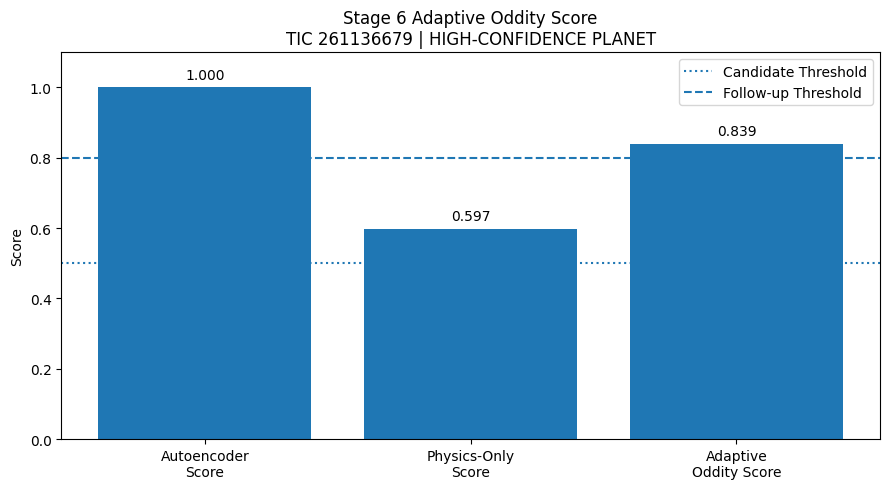

In [16]:
# ==========================================
# STAGE 6 SCORE VISUALIZATION
# ==========================================

labels = [
    "Autoencoder\nScore",
    "Physics-Only\nScore",
    "Adaptive\nOddity Score"
]

values = [
    autoencoder_score,
    physics_score,
    oddity_score
]

plt.figure(
    figsize=(9, 5)
)

bars = plt.bar(
    labels,
    values
)

plt.axhline(
    candidate_threshold,
    linestyle=":",
    label="Candidate Threshold"
)

plt.axhline(
    followup_threshold,
    linestyle="--",
    label="Follow-up Threshold"
)

for index, value in enumerate(values):

    plt.text(
        index,
        value + 0.025,
        f"{value:.3f}",
        ha="center"
    )

plt.ylim(
    0,
    1.10
)

plt.ylabel(
    "Score"
)

plt.title(
    f"Stage 6 Adaptive Oddity Score\n"
    f"TIC {tic_id} | {oddity_classification}"
)

plt.legend()

plt.tight_layout()

plt.show()

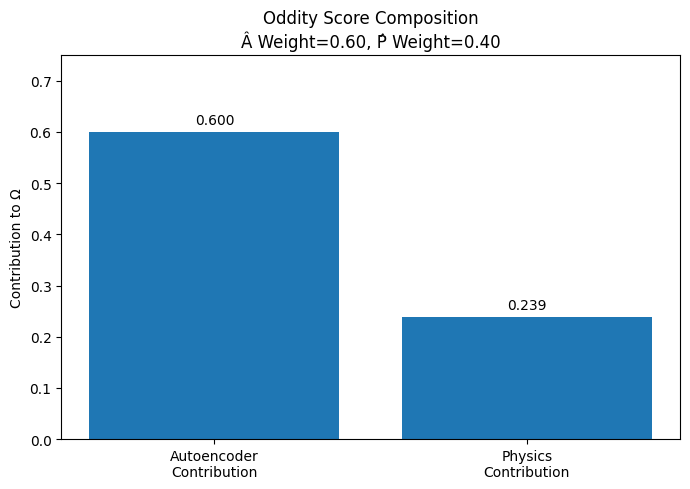

In [17]:
# ==========================================
# WEIGHTED CONTRIBUTION VISUALIZATION
# ==========================================

component_labels = [
    "Autoencoder\nContribution",
    "Physics\nContribution"
]

component_values = [
    autoencoder_component,
    physics_component
]

plt.figure(
    figsize=(7, 5)
)

bars = plt.bar(
    component_labels,
    component_values
)

for index, value in enumerate(
    component_values
):

    plt.text(
        index,
        value + 0.015,
        f"{value:.3f}",
        ha="center"
    )

plt.ylabel(
    "Contribution to Ω"
)

plt.title(
    f"Oddity Score Composition\n"
    f"Â Weight={autoencoder_weight:.2f}, "
    f"P̂ Weight={physics_weight:.2f}"
)

plt.ylim(
    0,
    max(
        0.70,
        max(component_values) + 0.15
    )
)

plt.tight_layout()

plt.show()

In [18]:
# ==========================================
# SAVE STAGE 6 OUTPUT
# ==========================================

stage6_output = {
    "tic_id": tic_id,

    "input_scores": {
        "autoencoder_score": float(
            autoencoder_score
        ),

        "physics_only_score": float(
            physics_score
        ),

        "original_stage5_score": safe_float(
            stage5.get(
                "physics_score"
            )
        )
    },

    "adaptive_context": {
        "blend_risk_value": float(
            blend_risk_value
        ),

        "blend_risk_level": (
            blend_risk_level
        ),

        "blend_risk_source": (
            blend_risk_source
        ),

        "normal_scatter": safe_float(
            normal_scatter
        ),

        "variability_class": (
            variability_class
        ),

        "autoencoder_reliable": bool(
            autoencoder_reliable
        ),

        "candidate_detected": bool(
            candidate_detected
        ),

        "reliability_reasons": (
            reliability_reasons
        )
    },

    "weighting": {
        "mode": weighting_mode,

        "autoencoder_weight": float(
            autoencoder_weight
        ),

        "physics_weight": float(
            physics_weight
        ),

        "reasons": weighting_reasons
    },

    "components": {
        "autoencoder_component": float(
            autoencoder_component
        ),

        "physics_component": float(
            physics_component
        )
    },

    "oddity_score": float(
        oddity_score
    ),

    "classification": (
        oddity_classification
    ),

    "recommendation": recommendation,

    "priority": priority,

    "warnings": stage6_warnings,

    "physics_only_metrics": (
        physics_only_metrics
    ),

    "physics_only_weights": (
        physics_only_weights
    ),

    "config": ODDITY_CONFIG
}

with open(
    stage6_path,
    "wb"
) as f:

    pickle.dump(
        stage6_output,
        f
    )

print(
    "Stage 6 output saved successfully!"
)

print(
    stage6_path
)

Stage 6 output saved successfully!
/content/drive/MyDrive/exoplanet_pipeline/data/stage6_output.pkl


In [19]:
# ==========================================
# VERIFY SAVED STAGE 6 OUTPUT
# ==========================================

with open(
    stage6_path,
    "rb"
) as f:

    saved_stage6 = pickle.load(f)

print(
    saved_stage6.keys()
)

print(
    "TIC ID:",
    saved_stage6[
        "tic_id"
    ]
)

print(
    "Oddity Score:",
    saved_stage6[
        "oddity_score"
    ]
)

print(
    "Classification:",
    saved_stage6[
        "classification"
    ]
)

print(
    "Recommendation:",
    saved_stage6[
        "recommendation"
    ]
)

print(
    "Weighting Mode:",
    saved_stage6[
        "weighting"
    ]["mode"]
)

dict_keys(['tic_id', 'input_scores', 'adaptive_context', 'weighting', 'components', 'oddity_score', 'classification', 'recommendation', 'priority', 'warnings', 'physics_only_metrics', 'physics_only_weights', 'config'])
TIC ID: 261136679
Oddity Score: 0.8387445388128465
Classification: HIGH-CONFIDENCE PLANET
Recommendation: RECOMMEND TELESCOPE FOLLOW-UP
Weighting Mode: QUIET_STAR_AUTOENCODER_PRIORITY
